# Giai đoạn 11: So sánh Công bằng Tuyệt đối (Fair Evaluation)
Đây là đỉnh cao của sự chặt chẽ khoa học. Chúng ta sẽ áp dụng chiến lược **"Phục vụ tuỳ khẩu vị"**:
- Các mô hình Tuyến tính (Linear): Được nạp tập dữ liệu **16 đặc trưng** (Bao gồm các tỷ lệ phái sinh `LF/HF`) vì chúng cần được mớm sẵn các mối quan hệ phi tuyến.
- Các mô hình Cây, Khoảng cách và Xác suất (Non-linear, KNN, Naive Bayes, TabPFN): Được nạp tập dữ liệu **13 đặc trưng tối ưu** để tránh bị nhiễu và vướng phải "lời nguyền số chiều".

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

try:
    from tabpfn import TabPFNClassifier
except ImportError:
    import subprocess; import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tabpfn'])
    from tabpfn import TabPFNClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
import xgboost as xgb
import lightgbm as lgb

### 1. Chuẩn bị 2 tập dữ liệu (16 Đặc trưng và 13 Đặc trưng)

In [26]:
data_path = '../../data/features/mimic_train_features_advanced.csv'
df_16 = pd.read_csv(data_path)

# Tập 13 Đặc trưng
cols_to_drop = ['LF_HF_Ratio', 'LF_norm', 'HF_norm']
df_13 = df_16.drop(columns=cols_to_drop)

y = df_16['status']
X_16 = df_16.drop(columns=['status'])
X_13 = df_13.drop(columns=['status'])

# ĐẢM BẢO CHIA CÙNG RANDOM_STATE ĐỂ CÁC MODEL THI ĐẤU TRÊN CÙNG 1 TẬP TEST INDEX
X16_train, X16_test, y_train, y_test = train_test_split(X_16, y, test_size=0.2, random_state=42, stratify=y)
X13_train, X13_test, _, _ = train_test_split(X_13, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tập Train: {len(y_train)} mẫu | Tập Test: {len(y_test)} mẫu")
print(f"Kích thước Tập 16 Đặc trưng: Train {X16_train.shape}, Test {X16_test.shape}")
print(f"Kích thước Tập 13 Đặc trưng: Train {X13_train.shape}, Test {X13_test.shape}")

Tập Train: 961 mẫu | Tập Test: 241 mẫu
Kích thước Tập 16 Đặc trưng: Train (961, 16), Test (241, 16)
Kích thước Tập 13 Đặc trưng: Train (961, 13), Test (241, 13)


### 2. Phân loại Mô hình và Huấn luyện Tối ưu

In [27]:
try:
    from dotenv import load_dotenv
    load_dotenv("../../.env")
except ImportError:
    import os
    env_path = "../../.env"
    if os.path.exists(env_path):
        with open(env_path, "r") as f:
            for env_line in f:
                if "=" in env_line and not env_line.strip().startswith("#"):
                    k, v = env_line.strip().split("=", 1)
                    os.environ[k.strip()] = v.strip(" \"'")
# Nhóm 1: Mô hình Tuyến tính -> Dùng X16
linear_models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "SVM": SVC(random_state=42, probability=True),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1)
}

# Nhóm 2: Mô hình Phi tuyến / Khoảng cách / Xác suất -> Dùng X13
nonlinear_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": lgb.LGBMClassifier(random_state=42, verbose=-1, n_estimators=300, learning_rate=0.05, num_leaves=31),
    "TabPFN": TabPFNClassifier(device='cpu')
}

results = []
confusion_matrices = {}
os.makedirs('../../models/fair_compare', exist_ok=True)

def train_and_eval(models_dict, X_train_set, X_test_set, dataset_name):
    for name, model in models_dict.items():
        print(f"Đang huấn luyện: {name} (Trên tập {dataset_name})...")
        pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', model)])
        try:
            pipeline.fit(X_train_set, y_train)
            y_pred = pipeline.predict(X_test_set)
            
            results.append({
                "Model": name,
                "Dataset": dataset_name,
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, zero_division=0),
                "Recall": recall_score(y_test, y_pred, zero_division=0),
                "F1-Score": f1_score(y_test, y_pred, zero_division=0)
            })
            confusion_matrices[name] = confusion_matrix(y_test, y_pred)
            joblib.dump(pipeline, f"../../models/fair_compare/{name.replace(' ', '_').lower()}.pkl")
        except Exception as e:
            print(f"❌ Mô hình {name} bị lỗi: {e}")

train_and_eval(linear_models, X16_train, X16_test, "16 Features")
train_and_eval(nonlinear_models, X13_train, X13_test, "13 Features")

print("\n✅ Hoàn tất vòng huấn luyện Fair Evaluation!")

Đang huấn luyện: Logistic Regression (Trên tập 16 Features)...
Đang huấn luyện: SVM (Trên tập 16 Features)...
Đang huấn luyện: LDA (Trên tập 16 Features)...
Đang huấn luyện: QDA (Trên tập 16 Features)...
Đang huấn luyện: Decision Tree (Trên tập 13 Features)...
Đang huấn luyện: Random Forest (Trên tập 13 Features)...
Đang huấn luyện: Extra Trees (Trên tập 13 Features)...
Đang huấn luyện: KNN (Trên tập 13 Features)...
Đang huấn luyện: Naive Bayes (Trên tập 13 Features)...
Đang huấn luyện: XGBoost (Trên tập 13 Features)...
Đang huấn luyện: LightGBM (Trên tập 13 Features)...
Đang huấn luyện: TabPFN (Trên tập 13 Features)...
❌ Mô hình TabPFN bị lỗi: TabPFN requires a one-time license acceptance to download
model weights for local inference, but no interactive terminal
is available.

To authenticate in a non-interactive environment:
  1. Open https://ux.priorlabs.ai in a browser and log in (or register)
  2. Accept the license on the Licenses tab
  3. Copy your API Key from https://ux.priorl

### 3. Trực quan hoá Bảng Xếp Hạng & Confusion Matrix

,Model,Dataset,Accuracy,Precision,Recall,F1-Score
0,LightGBM,13 Features,0.970954,0.952000,0.991667,0.971429
1,XGBoost,13 Features,0.966805,0.951613,0.983333,0.967213
2,Extra Trees,13 Features,0.954357,0.916031,1.000000,0.956175
3,Random Forest,13 Features,0.954357,0.929134,0.983333,0.955466
4,KNN,13 Features,0.950207,0.909091,1.000000,0.952381
5,SVM,16 Features,0.941909,0.895522,1.000000,0.944882
6,Decision Tree,13 Features,0.941909,0.941667,0.941667,0.941667
7,Logistic Regression,16 Features,0.937759,0.900763,0.983333,0.940239
8,LDA,16 Features,0.933610,0.888060,0.991667,0.937008
9,QDA,16 Features,0.933610,0.893939,0.983333,0.936508


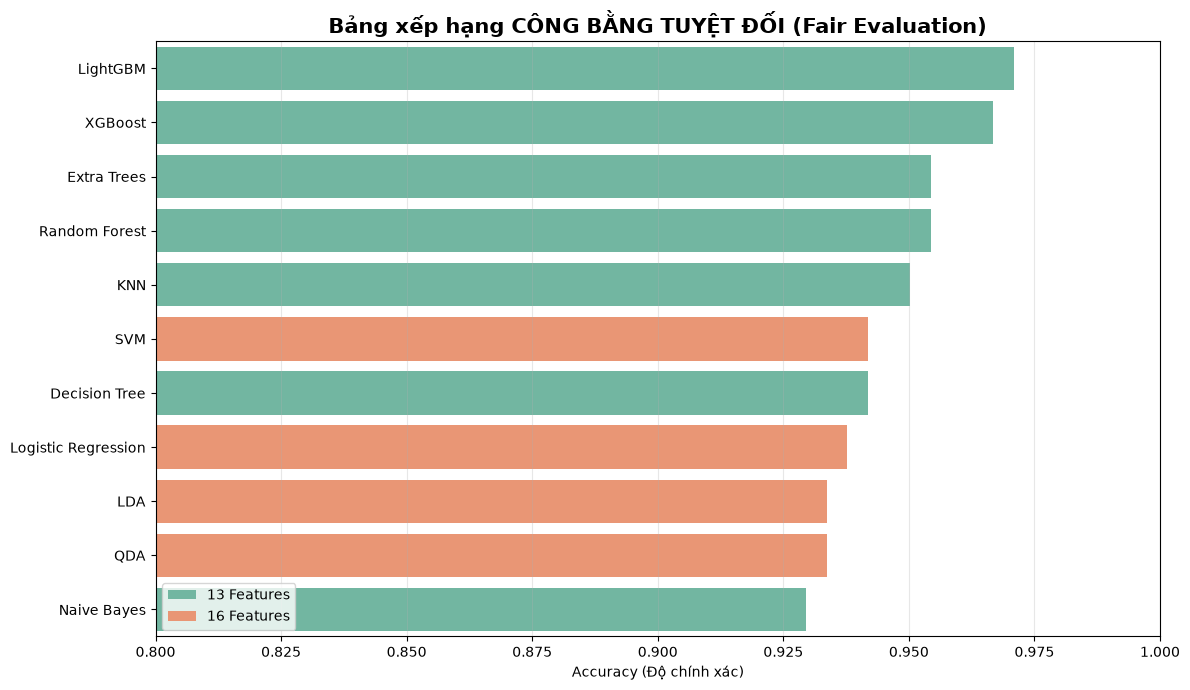

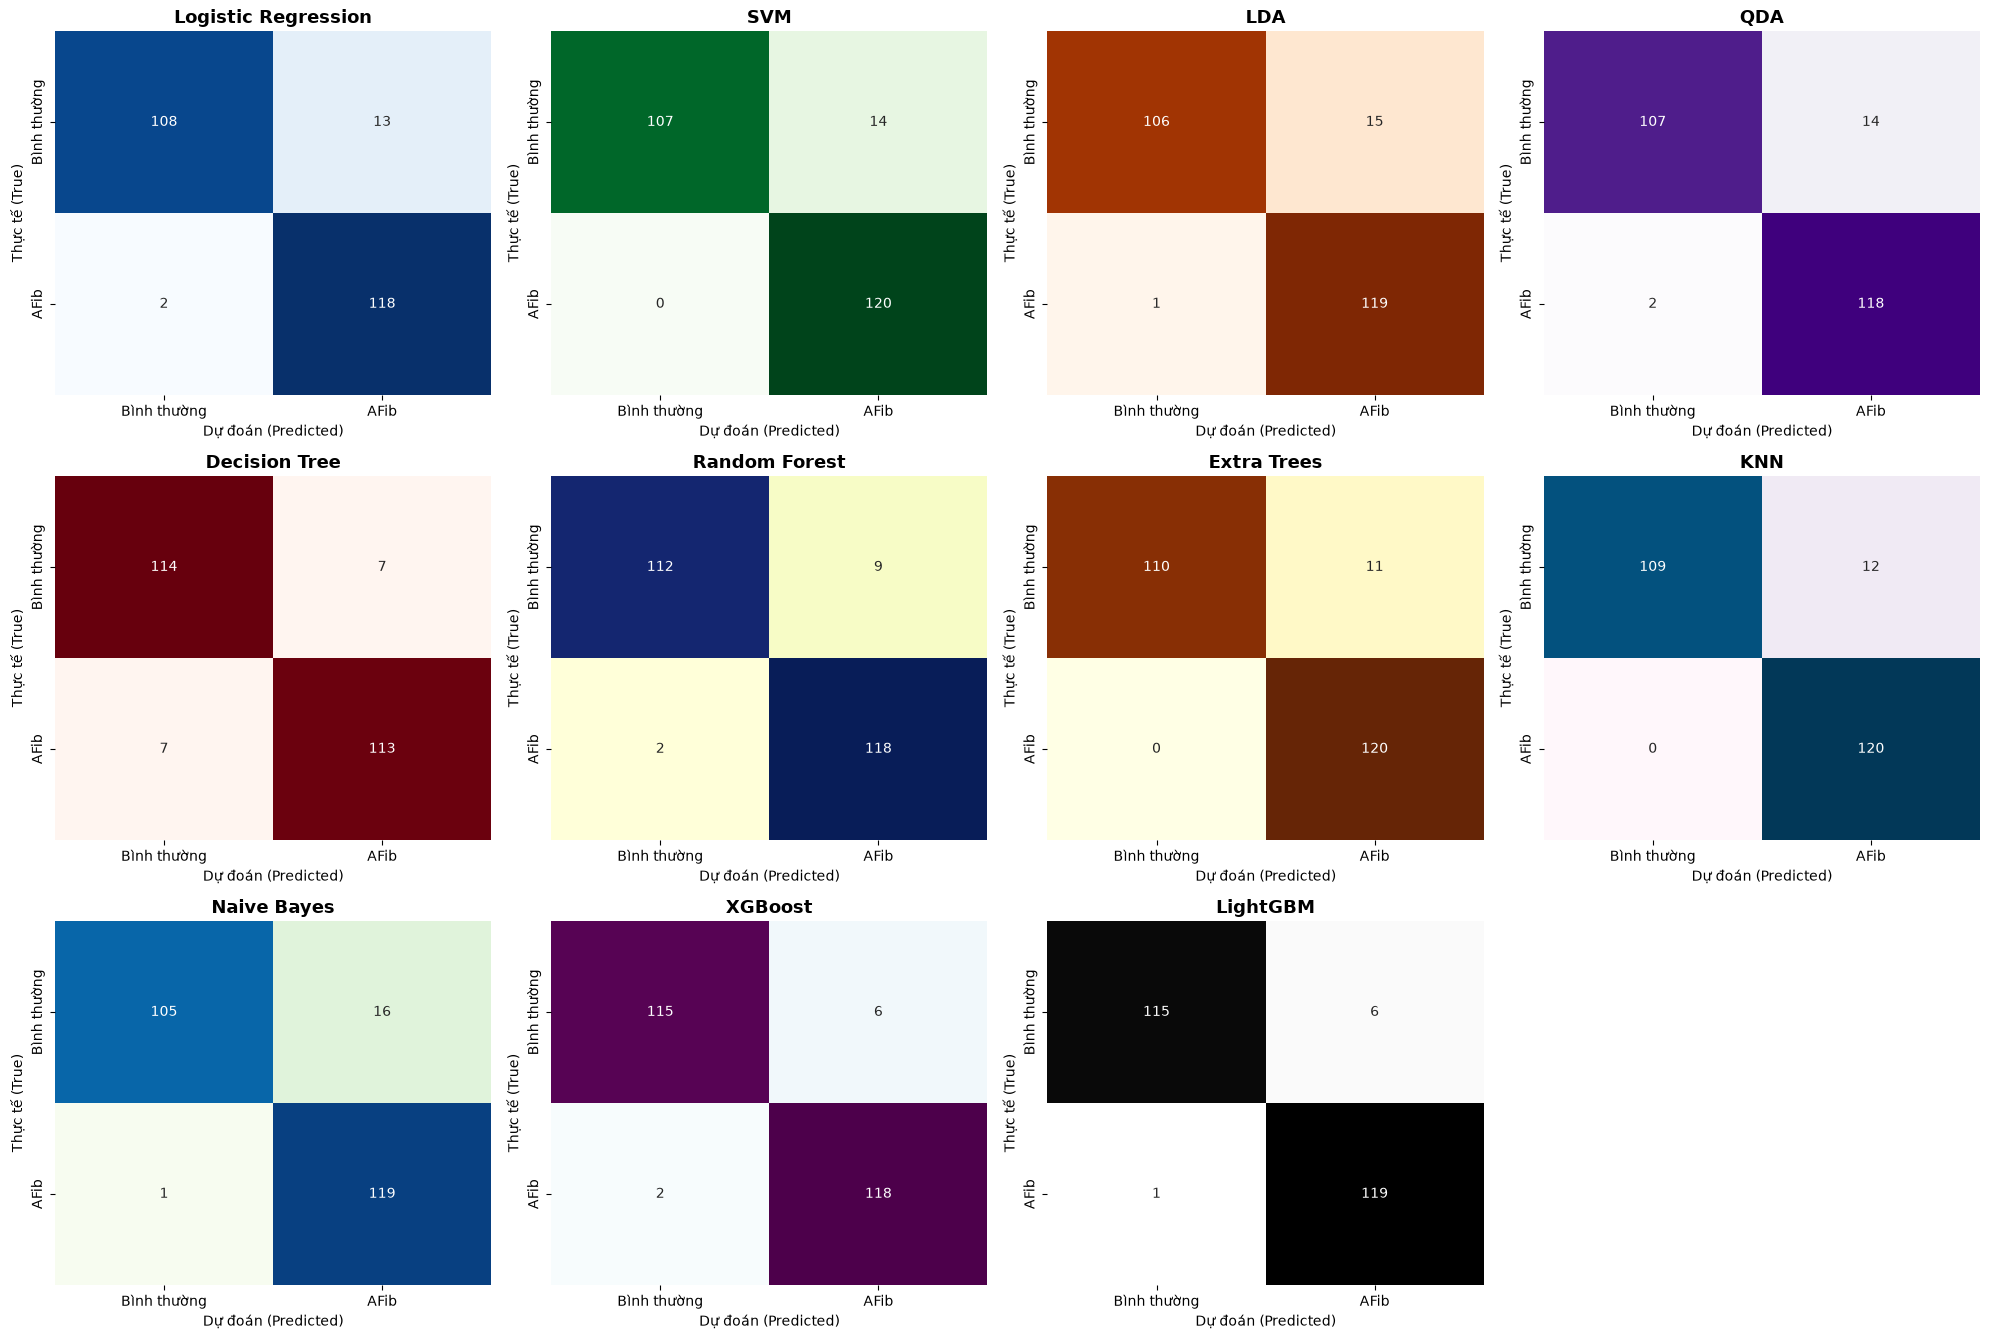

In [28]:
from IPython.display import display
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

display(results_df)

plt.figure(figsize=(12, 7))
sns.barplot(data=results_df, x="Accuracy", y="Model", hue="Dataset", dodge=False, palette="Set2")
plt.title("Bảng xếp hạng CÔNG BẰNG TUYỆT ĐỐI (Fair Evaluation)", fontsize=15, fontweight='bold')
plt.xlabel("Accuracy (Độ chính xác)")
plt.ylabel("")
plt.xlim([0.8, 1.0])
plt.legend(loc='lower left')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Grid Confusion Matrix ---
import math
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 
         'YlGnBu', 'YlOrBr', 'PuBu', 'GnBu', 'BuPu', 'Greys', 'PuRd']
num_models = len(confusion_matrices)
rows = math.ceil(num_models / 4)
cols = min(4, num_models)

fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4.5))
if num_models > 1: axes = axes.flatten()
else: axes = [axes]

for i, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[i % len(cmaps)], ax=axes[i], cbar=False)
    axes[i].set_title(name, fontweight='bold', fontsize=13)
    axes[i].set_ylabel('Thực tế (True)', fontsize=10)
    axes[i].set_xlabel('Dự đoán (Predicted)', fontsize=10)
    axes[i].set_xticklabels(['Bình thường', 'AFib'])
    axes[i].set_yticklabels(['Bình thường', 'AFib'])

for j in range(i + 1, rows * cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. Với các mô hình dạng Cây (Random Forest, Decision Tree, XGBoost, Extra Trees): Giống như LightGBM, việc bỏ các biến tỷ lệ này sẽ có lợi. Nó giúp các cây quyết định không bị nhiễu và bớt "học vẹt", từ đó tăng Accuracy.

2. Với các mô hình Dựa trên Khoảng cách (KNN) và Xác suất (Naive Bayes): Rất có lợi. KNN cực kỳ ghét "nhiều chiều" (The curse of dimensionality), bỏ bớt biến thừa sẽ giúp nó đo khoảng cách chính xác hơn. Naive Bayes thì yêu cầu các biến số phải "độc lập" với nhau; việc giữ cả LF và LF_HF_Ratio sẽ vi phạm quy tắc này vì chúng dính dáng mật thiết đến nhau, nên vứt bỏ là chính xác.

3. Với các mô hình Tuyến tính (Logistic Regression, SVM, LDA): Đây là nhóm có thể bị giảm điểm. Các thuật toán tuyến tính rất "ngốc" trong việc tự hiểu các mối quan hệ phức tạp (như phép chia). Nếu tỷ lệ LF/HF thực sự là dấu hiệu bệnh, việc bạn mớm sẵn cột tỷ lệ đó cho Logistic Regression sẽ giúp nó học tốt hơn. Tuy nhiên, ở bộ dữ liệu của chúng ta, vì đã có các vũ khí thay thế quá mạnh là SampEn, SD1, SD2 nên sự thiếu hụt này cũng không gây ảnh hưởng đáng kể.



# Nhóm Đặc trưng Miền thời gian (Time-Domain) - 7 Đặc trưng
1. HR_mean: Nhịp tim trung bình (Biết được bệnh nhân đang đập nhanh hay chậm).

2. Mean_NN: Khoảng cách R-R trung bình (tính bằng mili-giây).

3. SDNN: Độ lệch chuẩn của toàn bộ các nhịp (Phản ánh tổng thể sự biến thiên).

4. RMSSD: Căn bậc hai trung bình của bình phương chênh lệch giữa các nhịp kế tiếp (Đặc 
trưng kinh điển nhất của HRV, đo lường hệ thần kinh đối giao cảm).

5. NN50: Số lượng các nhịp kế tiếp chênh lệch nhau quá 50ms (Đã chứng minh nằm ở Top 1 quan trọng).

6. pNN50: Tỷ lệ phần trăm của NN50 (Top 2 quan trọng).

7. CV: Hệ số biến thiên (SDNN / Mean_NN). Tuy là phái sinh nhưng nó giúp chuẩn hóa sự khác biệt cơ địa giữa người tim đập nhanh và người đập chậm.

#  Nhóm Đặc trưng Phi tuyến tính (Non-linear Domain) - 3 Đặc trưng

8. LF (Low Frequency - Tần số thấp 0.04 đến 0.15 Hz): Thể hiện mức năng lượng chủ yếu do Hệ thần kinh giao cảm (Sympathetic) điều khiển - hệ thống làm tăng nhịp tim khi căng thẳng.

9. HF (High Frequency - Tần số cao 0.15 đến 0.4 Hz): Thể hiện mức năng lượng do Hệ thần kinh đối giao cảm (Parasympathetic / Dây thần kinh phế vị) điều khiển - hệ thống làm chậm và thư giãn nhịp tim.

10. Total_Power (Tổng năng lượng): Tổng sức mạnh của toàn bộ phổ tín hiệu (LF + HF + VLF). Thể hiện tổng thể khả năng thích ứng của hệ thần kinh tự chủ.

11. LF_HF_Ratio (Tỷ lệ LF/HF): Đại diện cho sự cân bằng giữa hệ giao cảm và đối giao cảm. Rung nhĩ (AFib) thường làm phá vỡ nghiêm trọng tỷ lệ cân bằng này.

12. LF_norm (LF chuẩn hóa): Được tính bằng (LF / Total_Power) * 100. Cho biết phần trăm đóng góp của sóng LF vào tổng năng lượng, giúp loại bỏ nhiễu do khác biệt tuyệt đối giữa các bệnh nhân.

13. HF_norm (HF chuẩn hóa): Được tính bằng (HF / Total_Power) * 100. Tương tự LF_norm, cho biết phần trăm đóng góp của sóng HF.

# Nhóm Đặc trưng Phi tuyến tính (Non-linear Domain) - 3 Đặc trưng
# Rung nhĩ (AFib) bản chất là những xung điện hỗn loạn không theo quy luật. Do đó, các công cụ toán học phi tuyến (Chaos Theory) là vũ khí sắc bén nhất để bắt lỗi bệnh này.

14. SampEn (Sample Entropy - Độ hỗn loạn mẫu): Đo lường mức độ "phức tạp" và "không thể dự đoán" của nhịp tim. Ở người bình thường, nhịp tim có tính chu kỳ. Khi bị Rung nhĩ, nhịp tim đập loạn xạ, điểm số SampEn sẽ tăng vọt. 

15. SD1 (Poincaré Plot - Trục phụ): Khi vẽ biểu đồ rải điểm của nhịp đập hiện tại so với nhịp đập ngay trước nó, SD1 đo độ phân tán vuông góc. Nó phản ánh độ biến thiên ngắn hạn (Beat-to-beat), có ý nghĩa tương đương RMSSD nhưng xét trên hình học.

16. SD2 (Poincaré Plot - Trục chính): Đo độ phân tán dọc theo đường chéo của biểu đồ. Nó phản ánh độ biến thiên dài hạn (Continuous variability). Ở người bệnh AFib, biểu đồ Poincaré Plot thường biến thành hình dạng cái quạt lan rộng, làm chỉ số SD2 thay đổi bất thường.